# Sieć dwuwarstwowa — Titanic (klasyfikacja binarna)

**Cel:** przewidzieć czy pasażer przeżył katastrofę (`Survived`: 0/1).

**Dataset:** 891 pasażerów, 7 cech wejściowych po usunięciu `PassengerId`

**Cechy:**
- `Pclass` — klasa biletu (1/2/3)
- `Sex` — płeć (0=kobieta, 1=mężczyzna, już zakodowane)
- `Age` — wiek znormalizowany do [0,1]
- `SibSp` — liczba rodzeństwa/małżonków na pokładzie
- `Parch` — liczba rodziców/dzieci na pokładzie
- `Embarked` — port zaokrętowania (C/Q/S)

**Architektura sieci:** 6 → 16 → 1

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.dpi'] = 100
os.makedirs('../plots', exist_ok=True)

print("Setup OK")

Setup OK


## 2. Preprocessing

### Decyzje:
| Kolumna | Akcja | Uzasadnienie |
|---------|-------|-------------|
| `PassengerId` | usuń | tylko indeks, bez wartości predykcyjnej |
| `Name` | usuń | zbyt unikalne wartości, nie nadaje się jako cecha |
| `Ticket` | usuń | j.w. |
| `Cabin` | usuń | 687/891 braków (77%) — za mało danych żeby wypełnić |
| `Age` | uzupełnij medianą z train | 177 braków, mediana bezpieczniejsza niż średnia (outliers) |
| `Embarked` | uzupełnij modą | tylko 2 braki |
| `Sex` | label encoding: male=1, female=0 | sieć wymaga liczb |
| `Embarked` | one-hot encoding | 3 kategorie → 2 kolumny binarne (drop_first) |
| `Pclass`, `Fare`, `Age`, `SibSp`, `Parch` | standaryzacja N(0,1) | ujednolicenie skali |

In [2]:
df = pd.read_csv('../data/titanic.csv')

# ── Krok 1: Usuń bezużyteczne kolumny ──
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
print(f"Po usunięciu kolumn: {df.shape}")

# ── Krok 2: Sex → 0/1 ──
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# ── Krok 3: Embarked → one-hot ──
# drop_first=True: C=0,0 | Q=1,0 | S=0,1 (unikamy multikolinearności)
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True).astype(int)
df = pd.concat([df, embarked_dummies], axis=1)
df = df.drop(columns=['Embarked'])

print(f"Kolumny po encodingu: {df.columns.tolist()}")
print(f"Kształt: {df.shape}")
df.head()

Po usunięciu kolumn: (891, 8)
Kolumny po encodingu: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
Kształt: (891, 9)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


## 3. Eksploracja danych

Sprawdzamy rozkład zmiennych i balans klas przed trenowaniem.

── Rozkład klasy docelowej ──
Survived
0    549
1    342
Name: count, dtype: int64

Balans: {0: 61.6, 1: 38.4} %


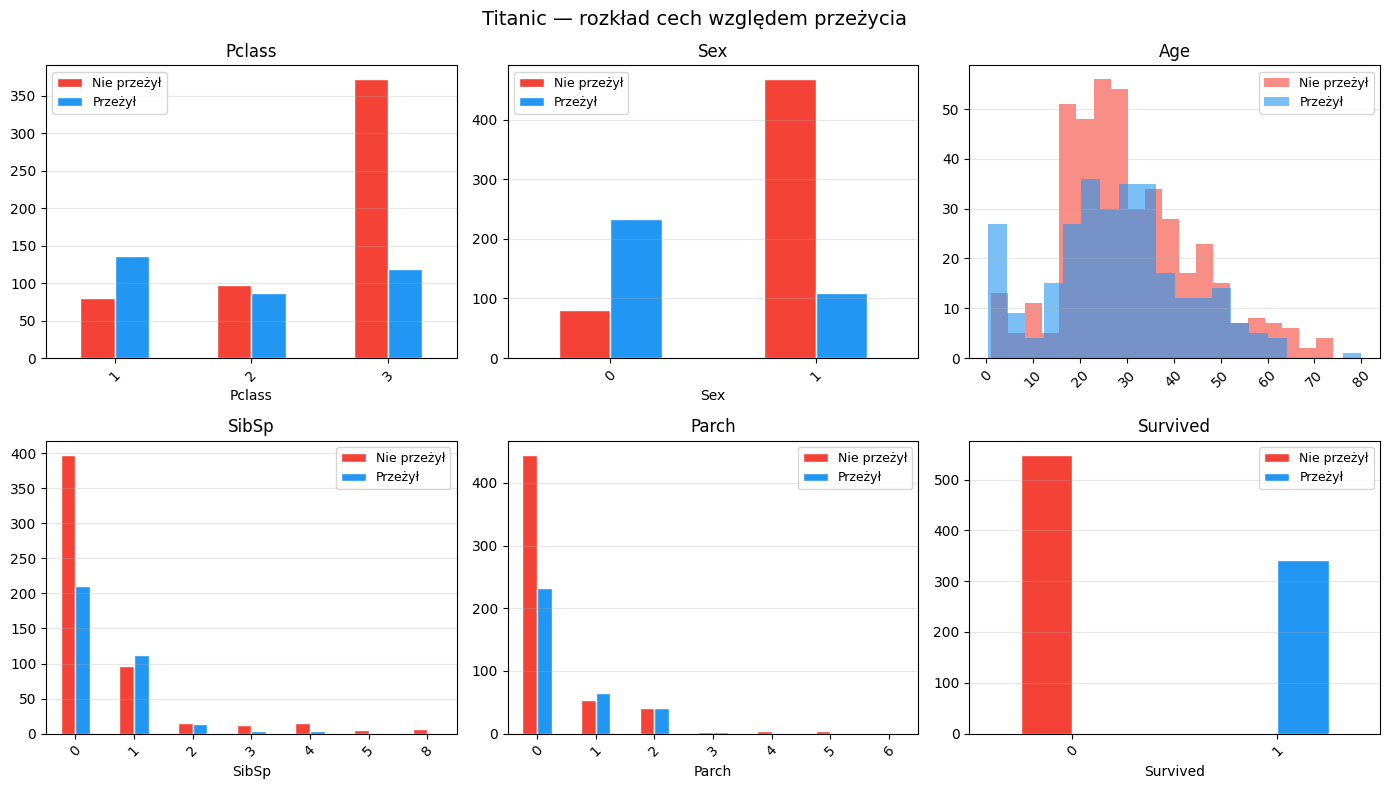

✓ Wykres zapisany


In [3]:
print(f"── Rozkład klasy docelowej ──")
counts = df['Survived'].value_counts()
print(counts)
print(f"\nBalans: {(counts / len(df) * 100).round(1).to_dict()} %")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

plot_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Survived']
for i, col in enumerate(plot_cols):
    if col == 'Age':
        # Histogram z podziałem na klasy
        for survived, color, label in [(0, '#F44336', 'Nie przeżył'), 
                                        (1, '#2196F3', 'Przeżył')]:
            axes[i].hist(df[df['Survived'] == survived][col],
                        bins=20, alpha=0.6, color=color, label=label)
        axes[i].legend(fontsize=9)
    else:
        crosstab = pd.crosstab(df[col], df['Survived'])
        crosstab.plot(kind='bar', ax=axes[i],
                     color=['#F44336', '#2196F3'], edgecolor='white')
        axes[i].legend(['Nie przeżył', 'Przeżył'], fontsize=9)

    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Titanic — rozkład cech względem przeżycia', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/titanic_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 4. Normalizacja i podział danych

Standaryzujemy cechy numeryczne do N(0,1). `Age` jest już w [0,1],
ale standaryzacja i tak nie zaszkodzi — ujednolicamy skalę wszystkich cech.

**Ważna zasada:** `StandardScaler` fitujemy **tylko na danych treningowych**,
żeby nie dopuścić do "przecieku" informacji testowych do modelu (data leakage).

In [4]:
# ── Cechy i target — pracujemy na DataFrame do końca preprocessingu ──
feature_cols = [c for c in df.columns if c != 'Survived']

# ── Podział PRZED wypełnianiem braków ──
X_df = df[feature_cols].copy()
y    = df['Survived'].values.astype(np.float32)

# Podział indeksów (stratyfikacja)
from sklearn.model_selection import train_test_split
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

X_train_df = X_df.iloc[idx_train].copy().reset_index(drop=True)
X_test_df  = X_df.iloc[idx_test].copy().reset_index(drop=True)
y_train    = y[idx_train]
y_test     = y[idx_test]

# ── Wypełnij braki Age medianą Z TRENINGU — na DataFrame ──
age_median_train = X_train_df['Age'].median()
print(f"Mediana Age (z treningu): {age_median_train:.2f}")
print(f"NaN Age przed: {X_train_df['Age'].isna().sum()}")

X_train_df['Age'] = X_train_df['Age'].fillna(age_median_train)
X_test_df['Age']  = X_test_df['Age'].fillna(age_median_train)

print(f"NaN Age po:    {X_train_df['Age'].isna().sum()}")

# ── Konwertuj na numpy float32 ──
X_train = X_train_df.values.astype(np.float32)
X_test  = X_test_df.values.astype(np.float32)

# ── Standaryzacja ──
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0) + 1e-8

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled  = (X_test  - train_mean) / train_std

# ── Weryfikacja końcowa ──
print(f"\n── Weryfikacja ──")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
for i, col in enumerate(feature_cols):
    nan_count = np.isnan(X_train_scaled[:, i]).sum()
    std_val   = train_std[i]
    flag = " ⚠️" if nan_count > 0 or std_val < 1e-7 else ""
    print(f"  {col:15s}: std={std_val:.4f}, NaN={nan_count}{flag}")

print(f"\nBalans train: {np.bincount(y_train.astype(int)) / len(y_train)}")
print(f"Balans test:  {np.bincount(y_test.astype(int))  / len(y_test)}")

Mediana Age (z treningu): 28.50
NaN Age przed: 137
NaN Age po:    0

── Weryfikacja ──
Train: 712 | Test: 179
  Pclass         : std=0.8330, NaN=0
  Sex            : std=0.4786, NaN=0
  Age            : std=13.0161, NaN=0
  SibSp          : std=1.0600, NaN=0
  Parch          : std=0.8375, NaN=0
  Fare           : std=48.0253, NaN=0
  Embarked_Q     : std=0.2670, NaN=0
  Embarked_S     : std=0.4467, NaN=0

Balans train: [0.61657303 0.38342697]
Balans test:  [0.61452514 0.38547486]


## 5. Trenowanie sieci

Architektura: **6 → 16 → 1**
- Wejście: 6 cech (Pclass, Sex, Age, SibSp, Parch + 2x Embarked one-hot = 8 cech)
- Warstwa ukryta: 16 neuronów z aktywacją ReLU
- Wyjście: 1 neuron z aktywacją Sigmoid (P(Survived=1))

`n_input` ustawiamy dynamicznie na podstawie rzeczywistej liczby cech.

In [5]:
from utils.models import TwoLayerNetwork

n_input = X_train_scaled.shape[1]
print(f"Liczba cech wejściowych: {n_input}")

model_titanic = TwoLayerNetwork(
    n_input=n_input,
    n_hidden=16,
    n_output=1,
    lr=0.01,
    mode='binary'
)

history = model_titanic.train_network(
    X_train_scaled, y_train,
    epochs=2000,
    batch_size=32,
    verbose=True
)

Liczba cech wejściowych: 8
Epoch     0/2000 | Loss: 1.055997 | Acc: 0.3834
Epoch   200/2000 | Loss: 0.396031 | Acc: 0.8385
Epoch   400/2000 | Loss: 0.379794 | Acc: 0.8455
Epoch   600/2000 | Loss: 0.373415 | Acc: 0.8469
Epoch   800/2000 | Loss: 0.363755 | Acc: 0.8567
Epoch  1000/2000 | Loss: 0.367944 | Acc: 0.8455
Epoch  1200/2000 | Loss: 0.360604 | Acc: 0.8596
Epoch  1400/2000 | Loss: 0.356663 | Acc: 0.8596
Epoch  1600/2000 | Loss: 0.345680 | Acc: 0.8581
Epoch  1800/2000 | Loss: 0.346317 | Acc: 0.8581


## 6. Wykresy uczenia

Trzy wykresy analizujące przebieg treningu:
- **Loss** — czy funkcja straty monotonicznie maleje?
- **Normy gradientów** — jak silnie aktualizowane były obie warstwy?
- **Accuracy** — kiedy model osiągnął stabilną dokładność?

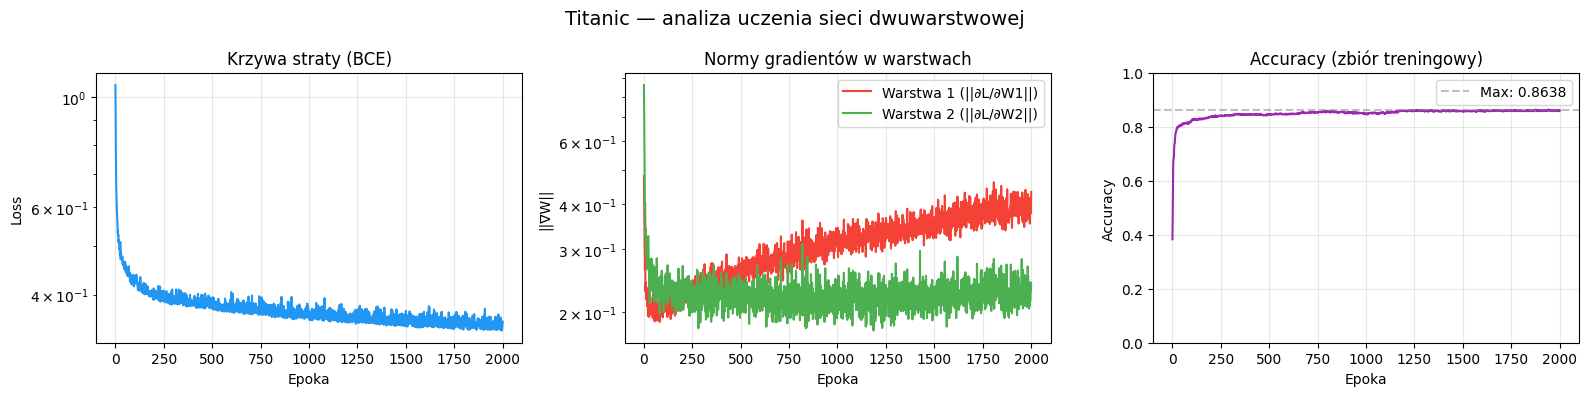

✓ Wykres zapisany


In [6]:
epochs_range = range(1, len(history['loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Loss ──
axes[0].plot(epochs_range, history['loss'], color='#2196F3', linewidth=1.5)
axes[0].set_title('Krzywa straty (BCE)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Loss')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# ── Gradienty warstw ──
axes[1].plot(epochs_range, history['grad_norm_W1'],
             label='Warstwa 1 (||∂L/∂W1||)', color='#F44336', linewidth=1.5)
axes[1].plot(epochs_range, history['grad_norm_W2'],
             label='Warstwa 2 (||∂L/∂W2||)', color='#4CAF50', linewidth=1.5)
axes[1].set_title('Normy gradientów w warstwach')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('||∇W||')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Accuracy ──
axes[2].plot(epochs_range, history['accuracy'], color='#9C27B0', linewidth=1.5)
axes[2].set_title('Accuracy (zbiór treningowy)')
axes[2].set_xlabel('Epoka')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1)
axes[2].axhline(y=max(history['accuracy']), color='gray',
                linestyle='--', alpha=0.5,
                label=f"Max: {max(history['accuracy']):.4f}")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Titanic — analiza uczenia sieci dwuwarstwowej', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/titanic_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 7. Ewaluacja na zbiorze testowym

Sprawdzamy jak model generalizuje na danych których nie widział podczas treningu.
Porównujemy macierz konfuzji i metryki precision/recall/F1.

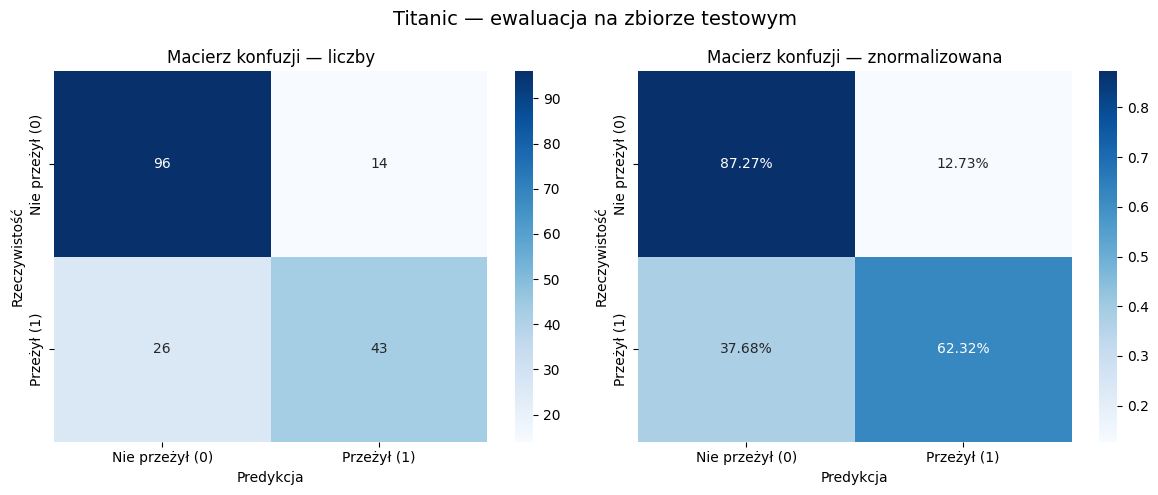

── Raport klasyfikacji ──
              precision    recall  f1-score   support

 Nie przeżył     0.7869    0.8727    0.8276       110
     Przeżył     0.7544    0.6232    0.6825        69

    accuracy                         0.7765       179
   macro avg     0.7706    0.7480    0.7551       179
weighted avg     0.7744    0.7765    0.7717       179



In [7]:
y_pred = model_titanic.predict(X_test_scaled)
y_proba = model_titanic.predict_proba(X_test_scaled)

# ── Macierz konfuzji ──
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Nie przeżył (0)', 'Przeżył (1)'],
            yticklabels=['Nie przeżył (0)', 'Przeżył (1)'])
axes[0].set_xlabel('Predykcja')
axes[0].set_ylabel('Rzeczywistość')
axes[0].set_title('Macierz konfuzji — liczby')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Nie przeżył (0)', 'Przeżył (1)'],
            yticklabels=['Nie przeżył (0)', 'Przeżył (1)'])
axes[1].set_xlabel('Predykcja')
axes[1].set_ylabel('Rzeczywistość')
axes[1].set_title('Macierz konfuzji — znormalizowana')

plt.suptitle('Titanic — ewaluacja na zbiorze testowym', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/titanic_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Raport klasyfikacji ──
print("── Raport klasyfikacji ──")
print(classification_report(y_test, y_pred,
                             target_names=['Nie przeżył', 'Przeżył'],
                             digits=4))

## 8. Wnioski

### Preprocessing
Dataset wymagał kilku kroków czyszczenia:
- `Age` miało 177 braków (19.9%) — uzupełniono medianą z danych treningowych
  (28.5 lat) żeby uniknąć data leakage
- `Cabin` usunięto (77% braków — zbyt mało danych do sensownego wypełnienia)
- `Embarked` miało 2 braki — uzupełniono modą
- `Sex` i `Embarked` zakodowano numerycznie (label encoding + one-hot)

### Przebieg uczenia
| Epoka | Loss | Accuracy (train) |
|-------|------|-----------------|
| 0 | 1.0560 | 38.34% |
| 200 | 0.3960 | 83.85% |
| 800 | 0.3638 | 85.67% |
| 2000 | ~0.346 | 86.38% (max) |

Sieć uczyła się bardzo dynamicznie w pierwszych 200 epokach — loss spadł
z 1.06 do 0.40, accuracy wzrosło z 38% do 84%. Po epokach 200-2000 poprawa
była powolna (~2 punkty procentowe), co sugeruje że model zbliżył się do
optimum dla tej architektury i tych danych.

Widoczne oscylacje norm gradientów (wykres środkowy) wynikają z mini-batch SGD
— każdy batch ma nieco inny rozkład danych co powoduje fluktuacje gradientu.
Warstwa 1 (czerwona) oscyluje silniej niż Warstwa 2 (zielona) — typowe
zjawisko: warstwa bliżej wejścia dostaje bardziej "zaszumiony" sygnał błędu
po przejściu przez W2.

### Wyniki na zbiorze testowym

| Metryka | Nie przeżył (0) | Przeżył (1) |
|---------|----------------|-------------|
| Precision | 0.7869 | 0.7544 |
| Recall | 0.8727 | 0.6232 |
| F1 | 0.8276 | 0.6825 |
| **Accuracy** | **0.7765** | |

Sieć poprawnie sklasyfikowała **139/179 pasażerów (77.65%)** na zbiorze testowym.

Analiza macierzy konfuzji:
- **96 TN** — model poprawnie przewidział śmierć pasażera
- **43 TP** — model poprawnie przewidział przeżycie
- **14 FP** — model błędnie przewidział przeżycie (pasażer zginął)
- **26 FN** — model przeoczył 26 ocalałych (przewidział śmierć)

Recall klasy "Przeżył" wynosi tylko 62.32% — model przeoczyć prawie 4 na 10
prawdziwych ocalałych. Wynika to z niezbalansowania klas (61.6% / 38.4%) oraz
faktu że przeżycie zależało od czynników losowych (np. kolejność wsiadania
do szalup) których dataset nie zawiera.

### Porównanie z Naiwnym Bayesem (subscribers)
Titanic osiągnął accuracy 77.65% vs 64.39% dla subscribers. Różnica wynika
głównie z jakości cech — na Titanicu cechy takie jak `Sex` i `Pclass` są
silnie korelowane z przeżyciem (kobiety i 1. klasa miały priorytet w szalupach),
podczas gdy cechy demograficzne subscribers słabo dyskryminują subskrypcję.